# AML Marker-Gene Audit — Global Joint UMAP (Test Highlighted) 

This notebook **loads the exact cached `adata_global` UMAP** produced by
`aml_multi_umap.ipynb` (its "Global Real Vs
Generated AML View" section, plus a small additive cache-to-disk cell appended there).

**Run `aml_multi_umap.ipynb` through its "Global
Real Vs Generated AML View" section at least once before this notebook**, so that
`output/cached_umap/aml_global_real_vs_generated_umap.h5ad` exists.

The train split is always shown as gray/black context, so it's possible to see
whether test-set patterns are specific to test or also visible in the train
region of the same embedding.

**Immune marker panels:** 3 immune-cell types
- **T cell**: CD3D, CD3E, CD8A
- **B cell**: CD19, MS4A1, CD79A
- **Monocyte / Macrophage**: CD14, CD68, LYZ

**Negative controls:** ACTB, HPRT1 (housekeeping; expected to be uniformly expressed).

**Analysis structure**

| # | Section | Visualisation |
|---|---------|---------------|
| 1 | Joint UMAP, Source Overview | Test cells colored by source (real/generated); train cells gray |
| 2 | Joint UMAP, Author's Cell-Type Labels | Test real cells colored by `CellType`; train real cells gray (generated cells excluded) |
| 3 | Per-gene expression overlays | Test real/generated cells colored by marker-gene expression; train cells gray, non-highlighted test source black |


In [1]:
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'  # avoid h5py lock errors on NFS-mounted home dirs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'output').exists() and (PROJECT_ROOT.parent / 'output').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
CACHE_PATH   = PROJECT_ROOT / 'output' / 'cached_umap' / 'aml_global_real_vs_generated_umap.h5ad'

CELLTYPE_KEY = 'CellType'

FOCUS_SPLIT = 'test'
OTHER_SPLIT = 'train'

# Immune marker panels for AML (3 immune cell types)
IMMUNE_MARKER_PANELS = {
    'T cell':                 ['CD3D', 'CD3E', 'CD8A'],
    'B cell':                 ['CD19', 'MS4A1', 'CD79A'],
    'Monocyte/Macrophage':    ['CD14', 'CD68', 'LYZ'],
}
NEGATIVE_CONTROL_GENES = ['ACTB', 'HPRT1']
ALL_IMMUNE_GENES = [g for panel in IMMUNE_MARKER_PANELS.values() for g in panel]
ALL_PANEL_GENES  = ALL_IMMUNE_GENES + NEGATIVE_CONTROL_GENES

SOURCE_COLORS = {'real': '#1976D2', 'generated': '#F4511E'}
ROW_COLORS    = {
    'T cell markers':              '#4CAF50',
    'B cell markers':              '#9C27B0',
    'Monocyte/Macrophage markers': '#FF5722',
    'Neg controls':                '#9E9E9E',
}
OTHER_SPLIT_COLOR  = 'lightgray'

sc.settings.verbosity = 1
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
print('Configuration loaded.')

Configuration loaded.


In [2]:
if not CACHE_PATH.exists():
    raise FileNotFoundError(
        f'{CACHE_PATH} not found. Run '
        f'aml_multi_umap.ipynb through its '
        f'"Global Real Vs Generated AML View" section first -- it now caches '
        f'adata_global there. This notebook loads that exact embedding rather than '
        f'recomputing it, so the UMAP layout is guaranteed to match.'
    )

adata_joint = ad.read_h5ad(CACHE_PATH)

missing_genes = [g for g in ALL_PANEL_GENES if g not in adata_joint.raw.var_names]
if missing_genes:
    print(f'WARNING: genes not found in cached embedding: {missing_genes}')

n_train = int((adata_joint.obs['split'] == 'train').sum())
n_test  = int((adata_joint.obs['split'] == 'test').sum())
print(f'Loaded cached embedding from {CACHE_PATH}: {adata_joint.n_obs} cells '
      f'({n_train} train, {n_test} test).')
adata_joint

Loaded cached embedding from output/cached_umap/aml_global_real_vs_generated_umap.h5ad: 43832 cells (33084 train, 10748 test).


AnnData object with n_obs × n_vars = 43832 × 4927
    obs: 'source', 'sample_id', 'split', 'CellType'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

## 1. Joint UMAP — Source Overview (Test Highlighted)

Uses the cached embedding loaded above (identical coordinates to the global view's
`adata_global`). Test cells are colored by `source` (real vs generated);
train cells are grayed into the background.



/share/conda-envs/scDiffusion/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


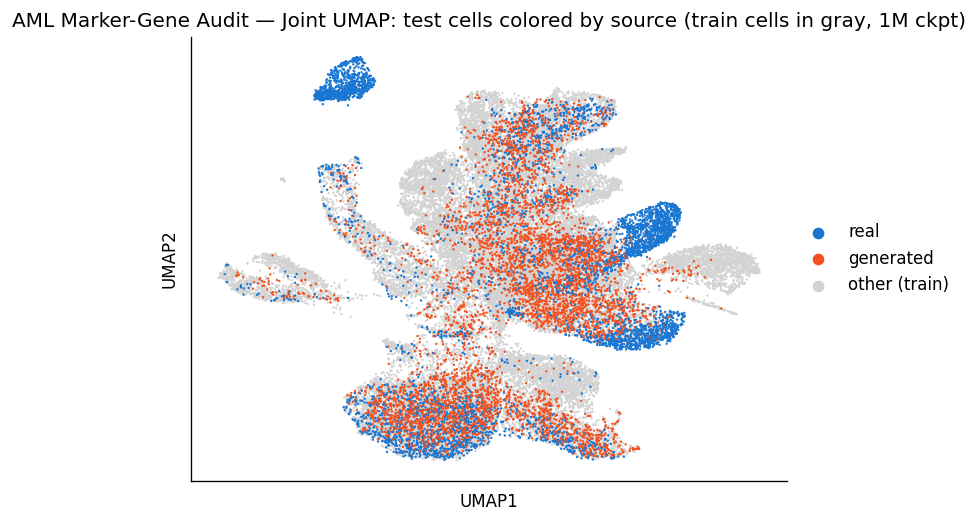

In [3]:
coords      = adata_joint.obsm['X_umap']
split_vals  = adata_joint.obs['split'].astype(str).values
source_vals = adata_joint.obs['source'].astype(str).values

is_focus    = split_vals == FOCUS_SPLIT
other_label = f'other ({OTHER_SPLIT})'

highlight = pd.Series(source_vals.copy())
highlight[~is_focus] = other_label
adata_joint.obs['highlight_source'] = pd.Categorical(
    highlight.values, categories=['real', 'generated', other_label]
)

# Draw background cells first so the highlighted split renders on top.
draw_order = np.argsort(is_focus)
palette = {**SOURCE_COLORS, other_label: OTHER_SPLIT_COLOR}

sc.pl.umap(
    adata_joint[draw_order],
    color='highlight_source',
    palette=palette,
    size=8,
    title=f'AML Marker-Gene Audit \u2014 Joint UMAP: {FOCUS_SPLIT} cells colored by source '
          f'({OTHER_SPLIT} cells in gray, 1M ckpt)',
)

## 2. Joint UMAP — Author's Cell-Type Labels (Test Real Cells)

Same embedding, restricted to **real cells only** (generated cells have no biological
label and are excluded entirely). Test real cells are colored by author
`CellType`; train real cells are grayed into the background.


/share/conda-envs/scDiffusion/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


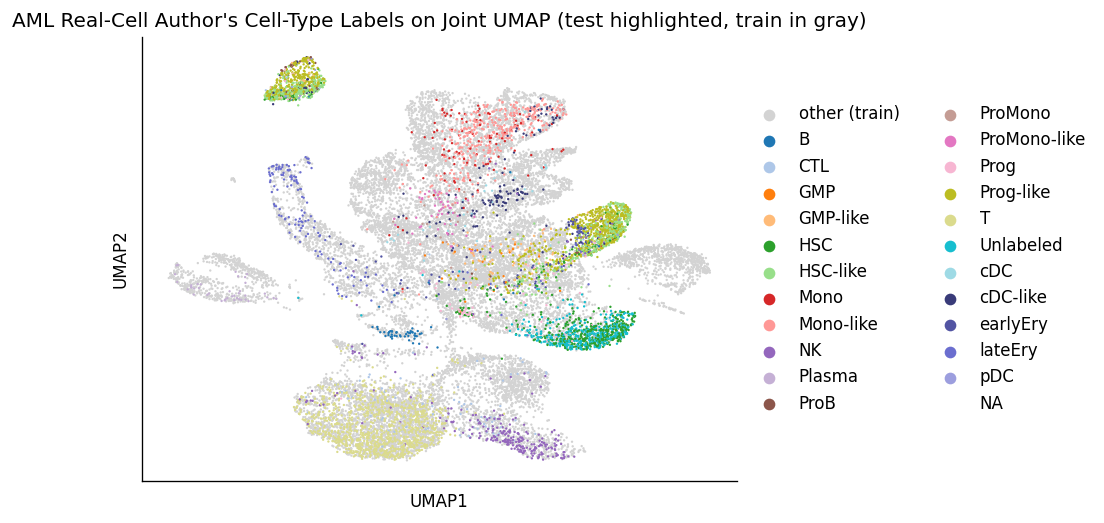

In [4]:
_RAW_PALETTE = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
# Drop grayscale-ish entries (tab20[14:16] and tab20c[16:20] are shades of gray) so no
# CellType color is ever confusable with the gray "other split" background.
_PALETTE   = [c for c in _RAW_PALETTE if max(c[:3]) - min(c[:3]) > 0.05]
_NULL_STRS = {'nan', 'None', 'NaN', 'none', 'NA', 'na', ''}

is_focus      = split_vals == FOCUS_SPLIT
is_real       = source_vals == 'real'
is_other_real = (~is_focus) & is_real
is_focus_real = is_focus & is_real

other_label = f'other ({OTHER_SPLIT})'

ct_vals = adata_joint.obs[CELLTYPE_KEY].astype(str).values
unique_cts = sorted(set(ct_vals[is_focus_real]) - _NULL_STRS)

# Generated cells (either split) get no category at all here -- left as NaN and
# rendered fully transparent via na_color, so they're excluded from this plot
# entirely rather than shown as a flat "other-source" color.
highlight_ct = np.full(adata_joint.n_obs, np.nan, dtype=object)
highlight_ct[is_other_real] = other_label
highlight_ct[is_focus_real] = ct_vals[is_focus_real]
adata_joint.obs['highlight_celltype'] = pd.Categorical(
    highlight_ct, categories=[other_label] + unique_cts
)

palette = {
    other_label: OTHER_SPLIT_COLOR,
    **{ct: _PALETTE[i % len(_PALETTE)] for i, ct in enumerate(unique_cts)},
}

# Draw order: other-split real cells in back, then focus-split real cells on top.
draw_order = np.argsort(is_focus_real.astype(int))

sc.pl.umap(
    adata_joint[draw_order],
    color='highlight_celltype',
    palette=palette,
    na_color=(0, 0, 0, 0),
    size=8,
    title=f"AML Real-Cell Author's Cell-Type Labels on Joint UMAP "
          f"({FOCUS_SPLIT} highlighted, {OTHER_SPLIT} in gray)",
)

/share/conda-envs/scDiffusion/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


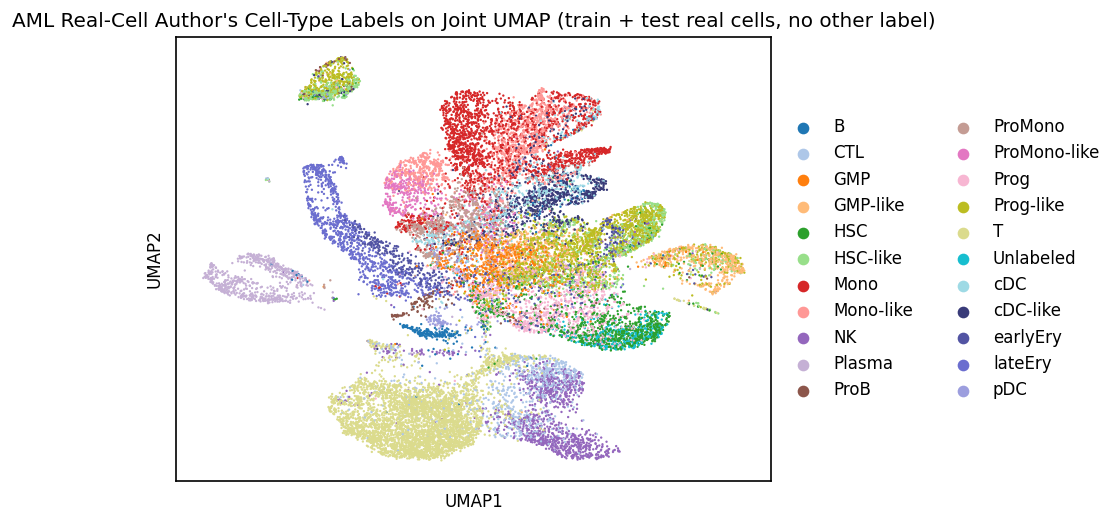

In [5]:
# All real cells from both train and test splits, colored directly by author CellType.
# Generated cells are omitted, and no synthetic "other" label is introduced.
ct_vals = adata_joint.obs[CELLTYPE_KEY].astype(str).values
is_real = source_vals == 'real'
is_labeled_real = is_real & ~np.isin(ct_vals, list(_NULL_STRS))
all_celltypes = sorted(set(ct_vals[is_labeled_real]) - _NULL_STRS)

adata_joint.obs['all_real_celltype'] = pd.Categorical(
    np.where(is_labeled_real, ct_vals, np.nan), categories=all_celltypes
)
all_real_palette = {
    ct: _PALETTE[i % len(_PALETTE)] for i, ct in enumerate(all_celltypes)
}

ax = sc.pl.umap(
    adata_joint[is_labeled_real],
    color='all_real_celltype',
    palette=all_real_palette,
    size=8,
    title="AML Real-Cell Author's Cell-Type Labels on Joint UMAP "
          "(train + test real cells, no other label)",
    frameon=True,
    show=False,
)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)
plt.show()


## 3. Per-Gene Expression Overlays on Joint UMAP

Renders each immune marker gene + negative control as a log1p colour overlay, in two
panels per gene: test-real-highlighted (left) and test-generated-highlighted
(right). Each panel shows only its own highlighted subset colored by expression;
train cells (either source) are gray context and the test cells of the
*non*-highlighted source are excluded from the panel entirely (not drawn at all),
so neither panel's gene-expression colouring can be confused with the other source's
cells. Colour scale (vmin/vmax) is shared by both panels, so the magma
intensity is directly comparable between the two panels; the spatial UMAP axes
are likewise pinned to the same x/y range across both panels.

Rows 1–3: immune-cell type markers (T cell, B cell, Monocyte/Macrophage).
Row 4: negative controls.

/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


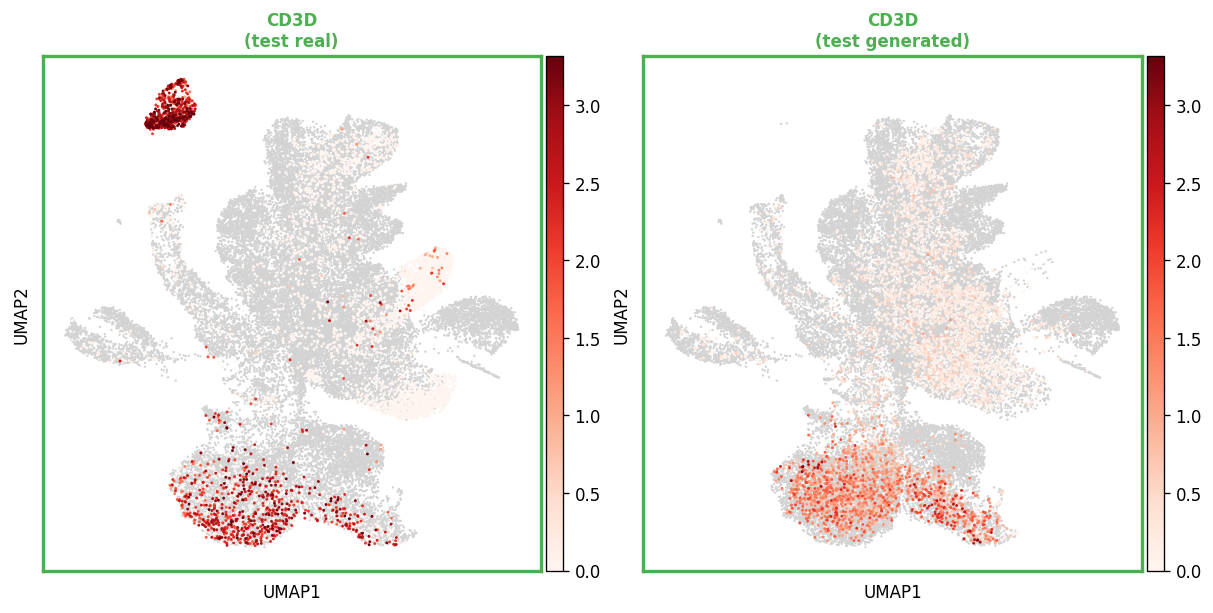

/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


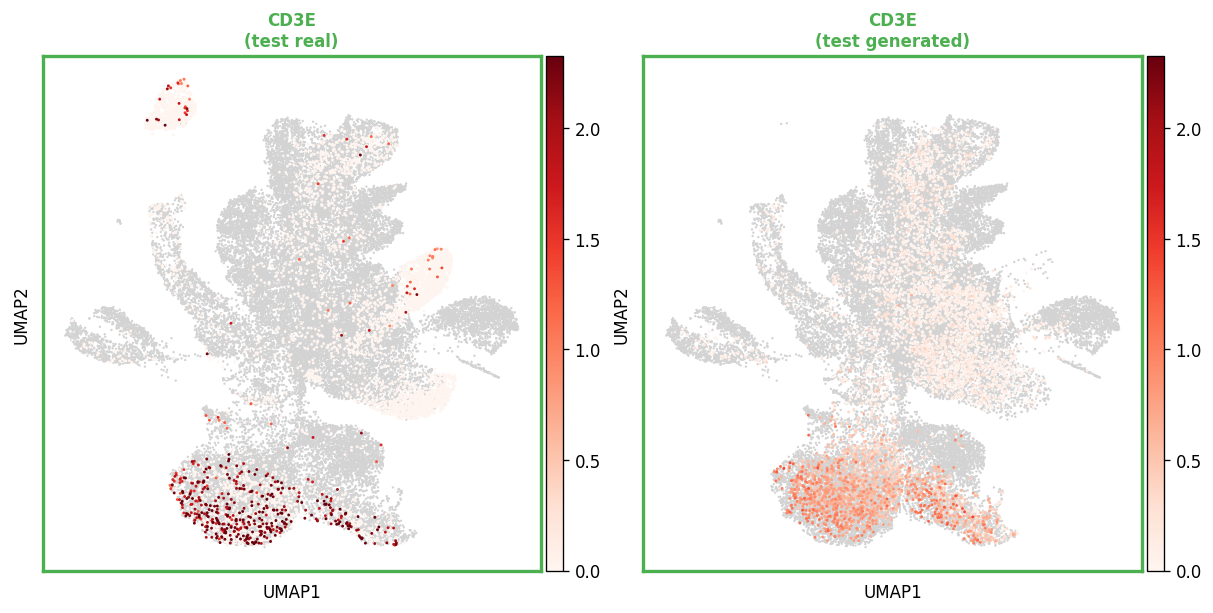

/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


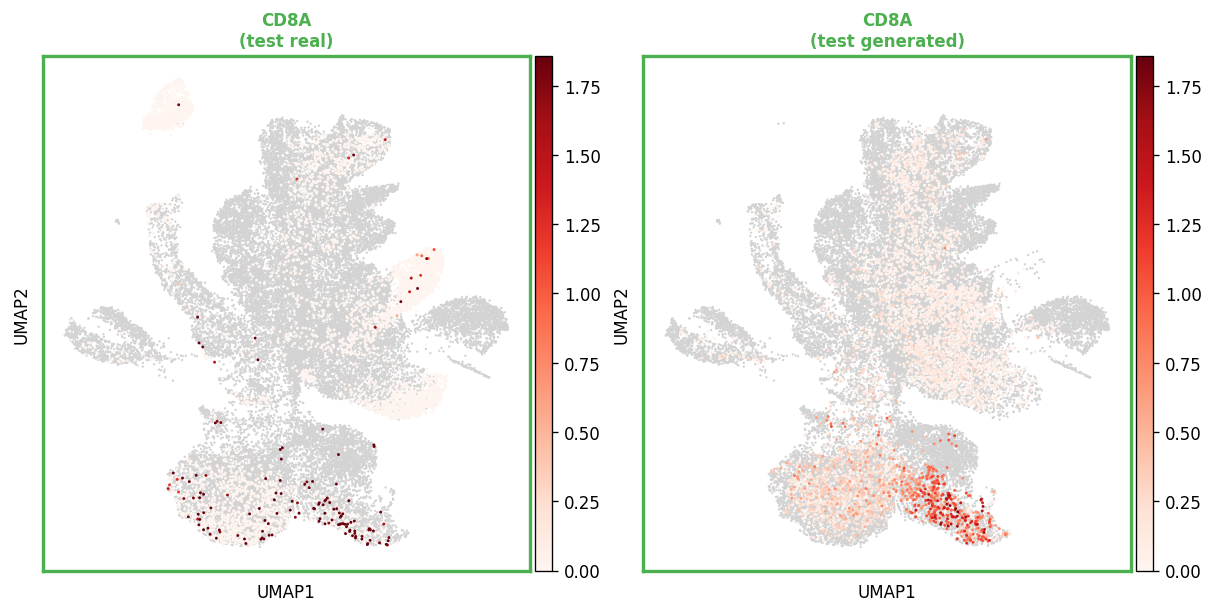

/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


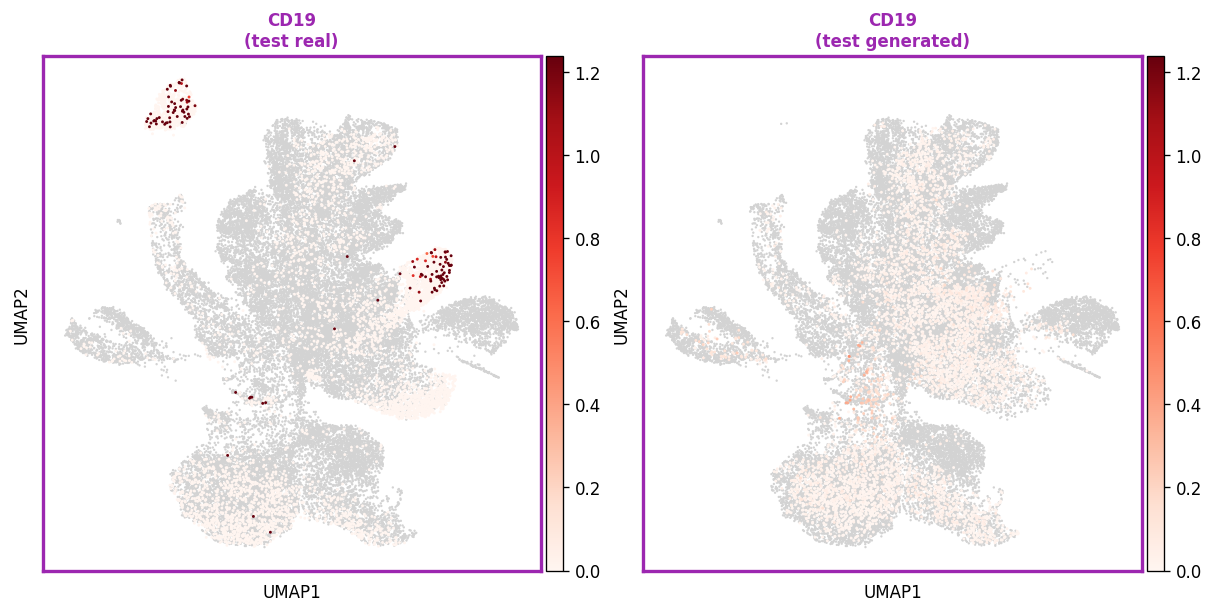

/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


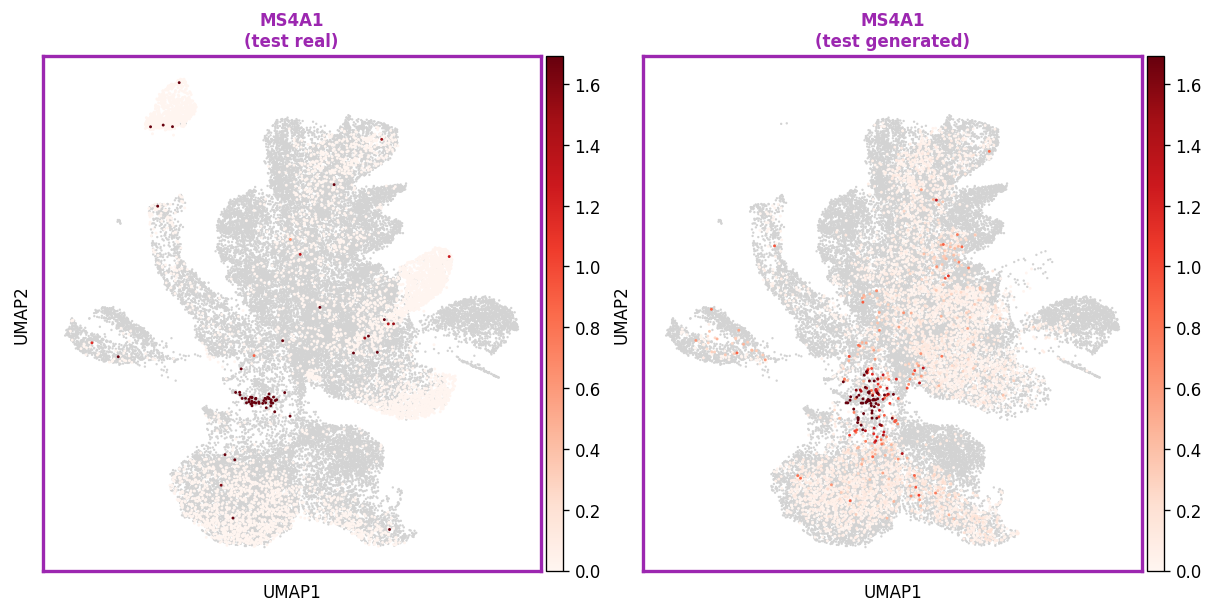

/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


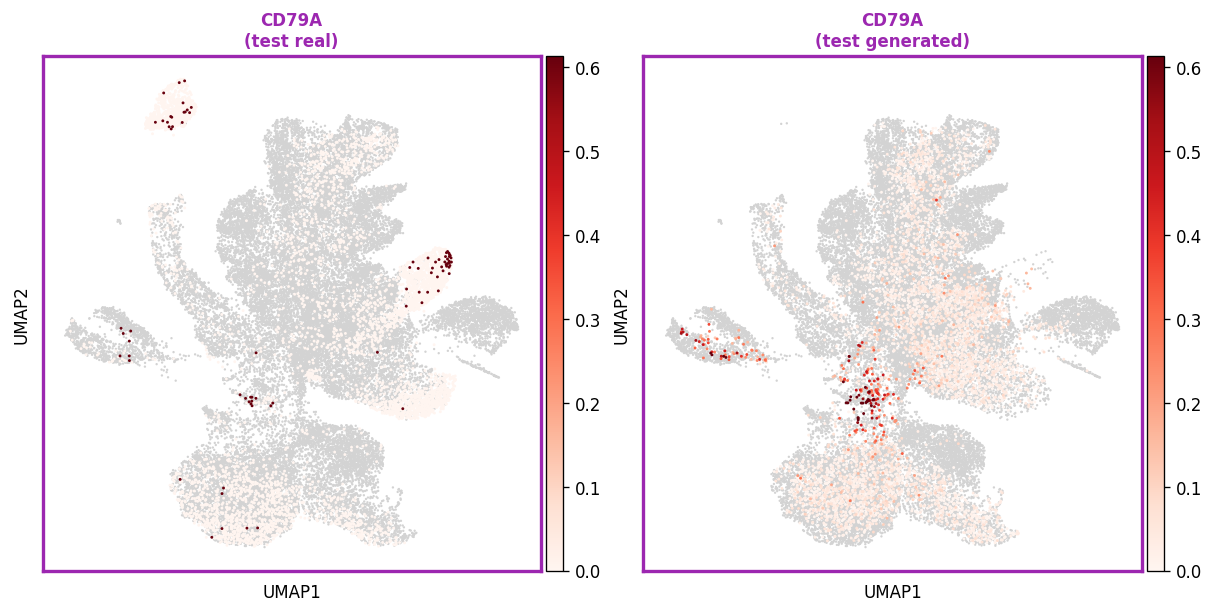

/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


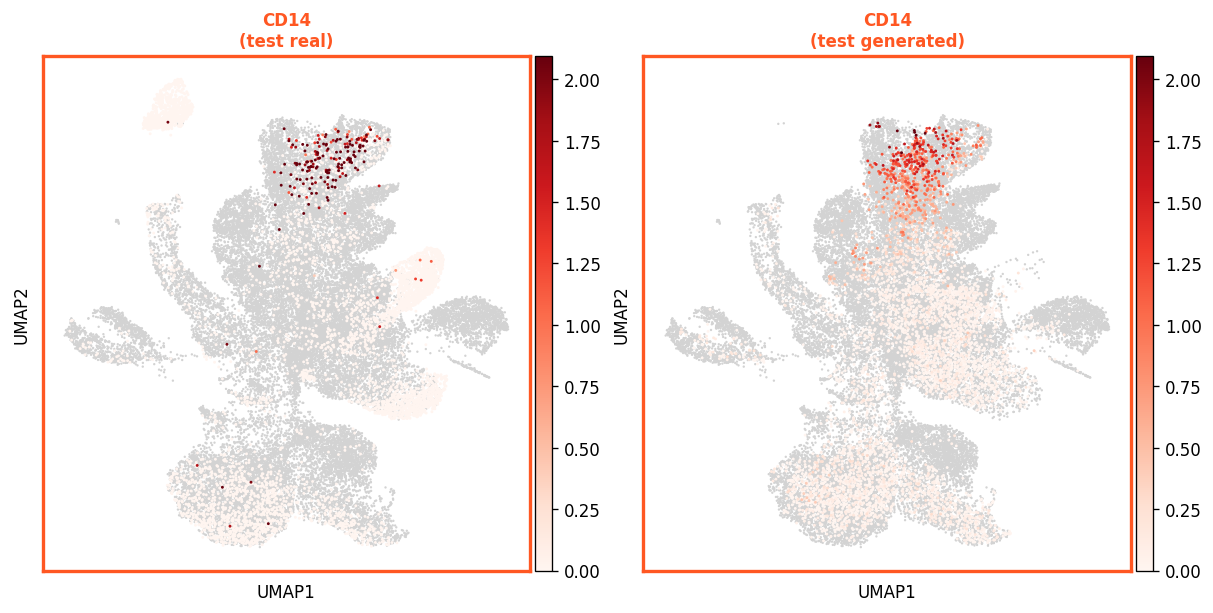

/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


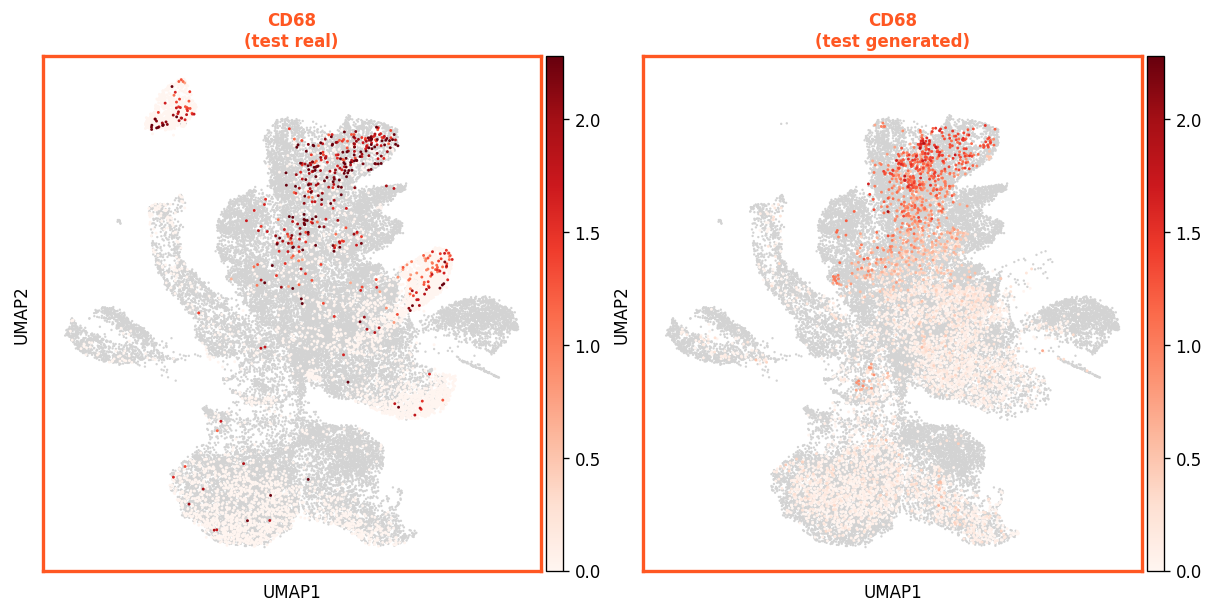

/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


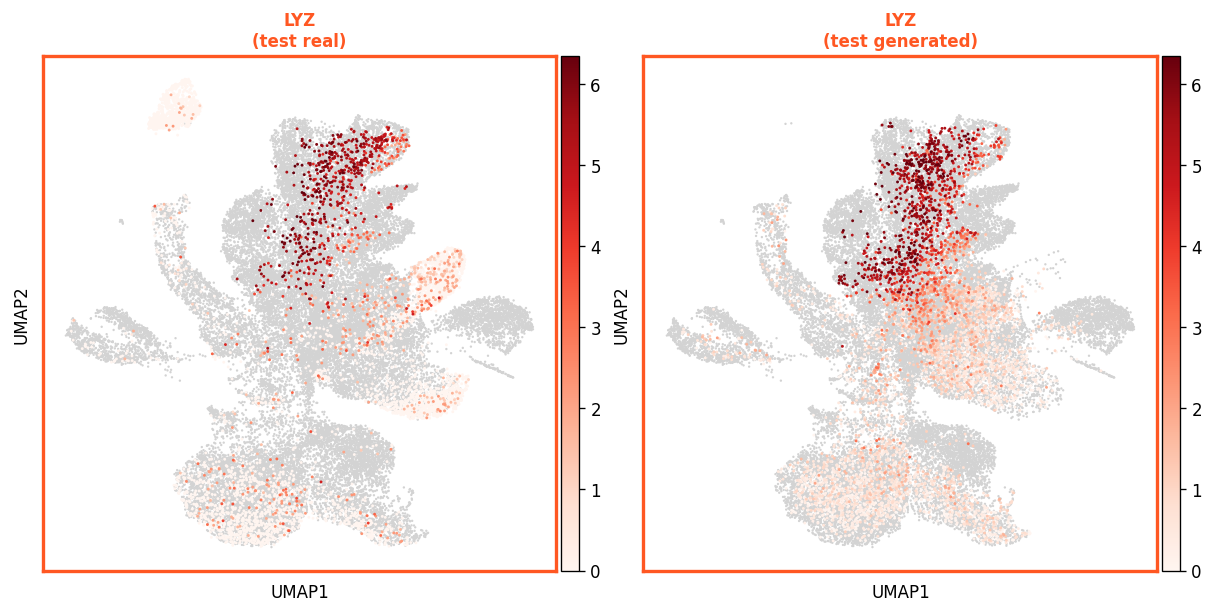

/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


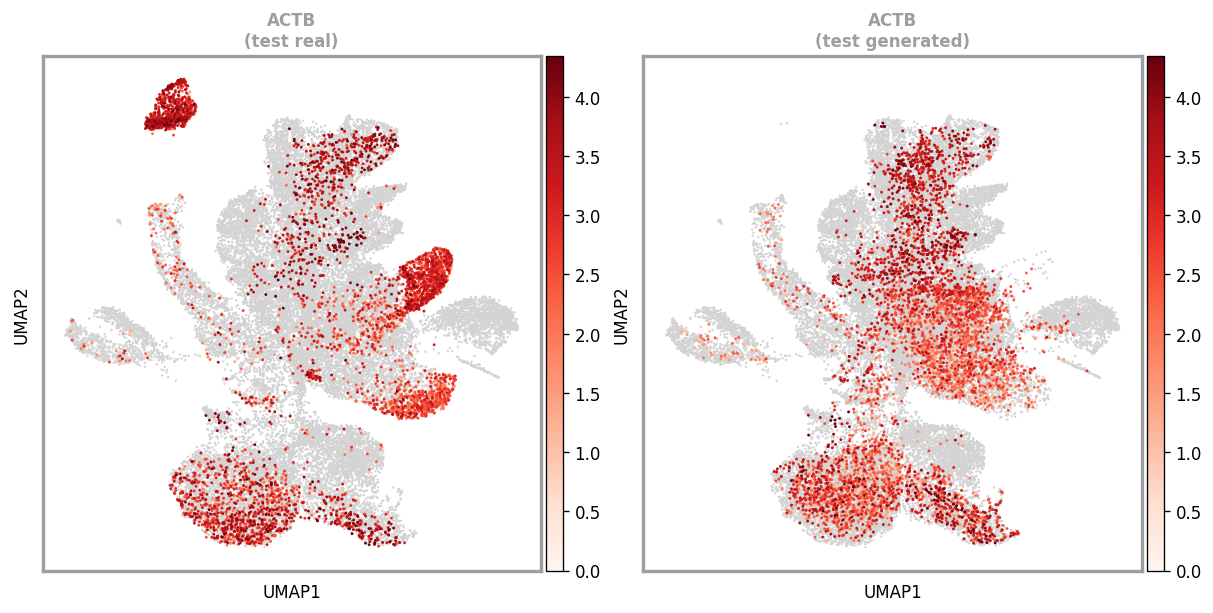

/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/share/conda-envs/scDiffusion/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


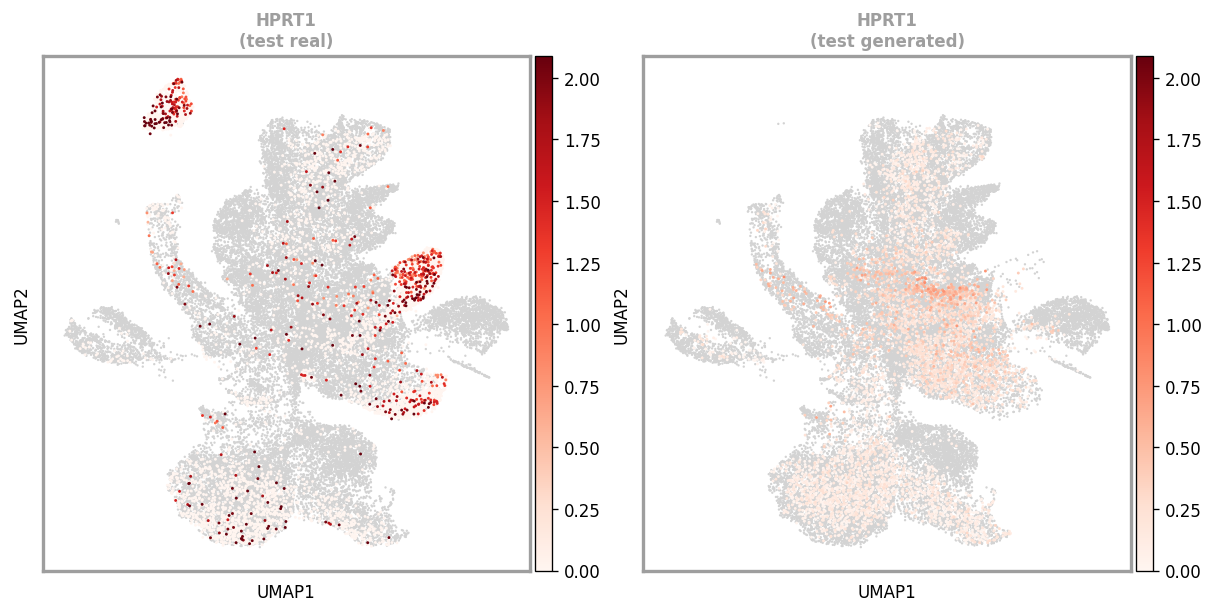

In [6]:
GENE_UMAP_BACKGROUND_DOT_SIZE = 8
GENE_UMAP_EXPRESSION_DOT_SIZE = 12
GENE_UMAP_CMAP = 'Reds'

gene_rows = [
    ('T cell markers',              IMMUNE_MARKER_PANELS['T cell']),
    ('B cell markers',              IMMUNE_MARKER_PANELS['B cell']),
    ('Monocyte/Macrophage markers', IMMUNE_MARKER_PANELS['Monocyte/Macrophage']),
    ('Neg controls',                NEGATIVE_CONTROL_GENES),
]

raw_var_names = list(adata_joint.raw.var_names)
raw_gene_idx  = {g: i for i, g in enumerate(raw_var_names)}
raw_X_src     = adata_joint.raw.X

is_focus      = split_vals == FOCUS_SPLIT
is_focus_real = is_focus & (source_vals == 'real')
is_focus_gen  = is_focus & (source_vals == 'generated')
is_other      = ~is_focus

marker_expr_cache = {}
for _, genes in gene_rows:
    for gene in genes:
        if gene in raw_gene_idx:
            col = raw_X_src[:, raw_gene_idx[gene]]
            if hasattr(col, 'toarray'):
                col = col.toarray().ravel()
            marker_expr_cache[gene] = np.asarray(col, dtype=np.float32)

# Single background tier, as a plain categorical column on adata_joint so each panel can be
# built from real sc.pl.umap() calls (matching Sections 1-2) instead of manual scatter.
other_label = f'other ({OTHER_SPLIT})'
bg_palette  = {other_label: OTHER_SPLIT_COLOR}

bg_other_only = np.full(adata_joint.n_obs, np.nan, dtype=object)
bg_other_only[is_other] = other_label
adata_joint.obs['_bg_other_only'] = pd.Categorical(bg_other_only, categories=[other_label])

# Both panels of every figure must share identical axis limits so the real- and
# generated-highlighted views are directly comparable. Each sc.pl.umap() layer only
# autoscales to the points it's actually given (NaN/background points don't reliably
# expand the axes the way a full categorical scatter does), so the two panels can end
# up with different ranges if left to their own autoscaling -- compute the true full
# embedding extent once and pin every panel's xlim/ylim to it explicitly.
_coords  = adata_joint.obsm['X_umap']
_x_pad   = (np.nanmax(_coords[:, 0]) - np.nanmin(_coords[:, 0])) * 0.05
_y_pad   = (np.nanmax(_coords[:, 1]) - np.nanmin(_coords[:, 1])) * 0.05
PANEL_XLIM = (np.nanmin(_coords[:, 0]) - _x_pad, np.nanmax(_coords[:, 0]) + _x_pad)
PANEL_YLIM = (np.nanmin(_coords[:, 1]) - _y_pad, np.nanmax(_coords[:, 1]) + _y_pad)


def _plot_gene_panel(ax, gene, vmax, highlight_mask, label, row_color):
    # Layer 1: full-data background, test-split cells only (train cells of both sources
    # are transparent here, regardless of which panel this is).
    sc.pl.umap(adata_joint, color='_bg_other_only', palette=bg_palette, na_color=(0, 0, 0, 0),
               size=GENE_UMAP_BACKGROUND_DOT_SIZE, ax=ax, show=False, legend_loc=None, title=None, frameon=True)
    # Layer 2: highlighted-subset gene expression, drawn on top.
    sc.pl.umap(adata_joint[highlight_mask], color=gene, use_raw=True, cmap=GENE_UMAP_CMAP,
               vmin=0, vmax=vmax, size=GENE_UMAP_EXPRESSION_DOT_SIZE, ax=ax, show=False, title=None, frameon=True)
    # Pin both panels to the same, full-embedding axis range (see note above).
    ax.set_xlim(PANEL_XLIM)
    ax.set_ylim(PANEL_YLIM)
    ax.set_title(f'{gene}\n({label})', fontsize=10, fontweight='bold', color=row_color)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(row_color); spine.set_linewidth(2.0); spine.set_visible(True)


is_focus_either = is_focus_real | is_focus_gen

# One figure per gene (2 panels: real-highlighted, generated-highlighted).
for row_label, genes in gene_rows:
    row_color = ROW_COLORS[row_label]
    for gene in genes:
        if gene not in marker_expr_cache:
            continue
        expr = marker_expr_cache[gene]
        # Shared colour scale (one vmax for both panels) -- if each panel were capped
        # at its own subset's 99th percentile independently, the two colorbars would
        # show different numeric ranges (e.g. 0-3.5 vs 0-2), making the magma color
        # intensity not directly comparable between real and generated.
        vmax_shared = float(np.nanpercentile(expr[is_focus_either], 99)) or 1.0

        fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
        # fig.suptitle(
        #     f'{row_label}: {gene}  |  {FOCUS_SPLIT} real-highlighted vs '
        #     f'{FOCUS_SPLIT} generated-highlighted\n'
        #     f'gray = {OTHER_SPLIT} cells  |  color = raw log1p expression (highlighted '
        #     f'subset only; the other {FOCUS_SPLIT} source is omitted from each panel)',
        #     fontsize=12, fontweight='bold',
        # )
        _plot_gene_panel(axes[0], gene, vmax_shared, is_focus_real,
                          f'{FOCUS_SPLIT} real', row_color)
        _plot_gene_panel(axes[1], gene, vmax_shared, is_focus_gen,
                          f'{FOCUS_SPLIT} generated', row_color)
        plt.show()